In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor, WhisperForConditionalGeneration,
    WhisperFeatureExtractor, WhisperTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments)
from jiwer import wer, cer
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import re
import os
import json
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


This one is crucial for setting up the environment and verifying our hardware before proceeding with the main tasks. Here's a breakdown:

- *numpy*: For numerical operations, especially with arrays.
- *torch*: The PyTorch deep learning framework, essential for model operations.
- *matplotlib.pyplot and matplotlib.ticker*: For creating various plots and customizing their axes.
- *from datasets import load_dataset, Audio*: Imports load_dataset for fetching datasets from the Hugging Face Hub and Audio for handling audio data.
- *transformers*: Imports various components from the Hugging Face transformers library, which is central to this project:
  - *WhisperProcessor*: Handles both feature extraction and tokenization for the Whisper model.
  - *WhisperForConditionalGeneration*: The actual Whisper model architecture.
  - *WhisperFeatureExtractor*: Extracts audio features (like mel spectrograms) from raw audio.
  - *WhisperTokenizer*: Converts text to token IDs and vice-versa.
  - *Seq2SeqTrainer, Seq2SeqTrainingArguments*: Tools for fine-tuning sequence-to-sequence models.
- *from jiwer import wer, cer*: Imports functions to calculate Word Error Rate (WER) and Character Error Rate (CER), common metrics for ASR models.
- *from dataclasses import dataclass, from typing import Any, Dict, List, Union* These are standard Python modules for defining data classes and type hinting, which improve code readability and maintainability.

- *import re, os, json, warnings*: re: For regular expressions (regex). os: For interacting with the operating system (e.g., file paths).json: For working with JSON data. warnings: For controlling warning messages, with warnings.filterwarnings('ignore') suppressing all warnings.
- `print(f'Device: {'cuda' if torch.cuda.is_available() else 'cpu'}')`: This line checks if a CUDA-enabled GPU is available and prints whether the device being used is cuda (GPU) or cpu.

- `print(f'GPU: {torch.cuda.get_device_name(0)}')`: If a GPU is available, this prints the name of the first detected GPU (e.g., 'Tesla T4').

- `print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')`If a GPU is available, this prints the total video RAM (VRAM) of the first GPU in gigabytes, rounded to one decimal place. This is important for understanding memory limitations for model sizes and batch sizes.

# PART A - Baseline ASR: Dataset Load, Inference & Evaluation

## A1. Dataset Preparation

In [ ]:
ds_test = load_dataset("fsicoli/common_voice_22_0", "az",  split = 'test', streaming = False, trust_remote_code=True)

print(f'Test set size: {len(ds_test)} samples')
print(f'Features: {list(ds_test.features.keys())}')
print('Sample entry:')
print(json.dumps({k: str(v)[ : 80] for k, v in ds_test[0].items() if k != 'audio'}, indent = 2, ensure_ascii = False))

Generating train split: 0 examples [00:00, ? examples/s]


Reading metadata...: 157it [00:00, 43031.15it/s]


Generating validation split: 0 examples [00:00, ? examples/s]


Reading metadata...: 78it [00:00, 46863.73it/s]


Generating test split: 0 examples [00:00, ? examples/s]

...

Generating other split: 0 examples [00:00, ? examples/s]


Reading metadata...: 529it [00:00, 65880.42it/s]


Generating invalidated split: 0 examples [00:00, ? examples/s]


Reading metadata...: 50it [00:00, 53911.36it/s]


Test set size: 95 samples
Features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant']
Sample entry:
{
  "client_id": "c92feeeea5101fc79ef7d4e7a2e5b978ea7c8f4cc72cbe07e60261724c6a9ba9eccd1b9f4217e5ab",
  "path": "/root/.cache/huggingface/datasets/downloads/extracted/b17a59c6aaae7cf3a185c27ecf",
  "sentence": "Yarada iki əsas dəyişiklik baş verir.",
  "up_votes": "2",
  "down_votes": "1",
  "age": "",
  "gender": "",
  "accent": "",
  "locale": "az",
  "segment": "",
  "variant": ""
}


This code block's main purpose is to load the Azerbaijani test split of the `fsicoli/common_voice_22_0` dataset using the Hugging Face `datasets` library. It then prints the total number of samples, lists the available features, and displays a truncated version of the first sample's metadata to give a quick overview of the data's structure and content.

In [ ]:
ds_test = ds_test.cast_column('audio', Audio(sampling_rate = 16000))

# Use a manageable subset for evaluation
eval_size = min(100, len(ds_test))
ds_eval = ds_test.select(range(eval_size))
print(f'Evaluation subset: {eval_size} samples @{16000} Hz')

Evaluation subset: 95 samples @16000 Hz


This code block first recasts the 'audio' column to a uniform sampling rate of 1600 Hz for ASR model compatibility. It then creates an evaluation subset (`ds_eval`) by selecting up to 100 samples from the dataset. Finally, it prints a confirmation message showing the size and sampling rate of this evaluation subset.

## A2. Model Selection & Inference - `openai/whisper-small`

In [ ]:
processor = WhisperProcessor.from_pretrained('openai/whisper-small')
model_base = WhisperForConditionalGeneration.from_pretrained('openai/whisper-small').to(device)
model_base.eval()
# Force Azerbaijani language during generation
model_base.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language = 'azerbaijani', task = 'transcribe')

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

This code block initializes the Whisper processor and the `openai/whisper-small` model for conditional generation, moving it to the GPU if available. It then sets the model to evaluation mode and configures it to specifically generate transcriptions in Azerbaijani.

In [ ]:
def transcribe_batch(model, samples, batch_size = 8):
    # Run Whisper inference on a list of Common Voice samples
    predictions = [ ]
    for i in range(0, len(samples), batch_size):
        batch = samples[i : i + batch_size]
        audios = [s['audio']['array'] for s in batch]

        # Extract mel features for each audio individually
        mel_features = [ ]
        for audio in audios:
            feat = processor.feature_extractor(audio, sampling_rate = 16000, return_tensors = "np").input_features[0]
            mel_features.append(feat)

        # Explicitly pad/truncate to exactly 3000 frames (Whisper requirement)
        n_mels = mel_features[0].shape[0]
        padded = np.zeros((len(mel_features), n_mels, 3000), dtype = np.float32)
        for j, feat in enumerate(mel_features):
            length = min(feat.shape[1], 3000)
            padded[j, :, :length] = feat[:, :length]

        input_features = torch.tensor(padded).to(device)
        with torch.no_grad(): generated = model.generate(input_features = input_features)

        decoded = processor.batch_decode(generated, skip_special_tokens = True)
        predictions.extend(decoded)

        processed = min(i + batch_size, len(samples))
        if (i // batch_size + 1) % 5 == 0 or processed == len(samples):
          print(f'processed {processed}/{len(samples)} samples')
    return predictions

# Baseline inference
eval_samples_list = [ds_eval[i] for i in range(eval_size)]
references_raw = [s['sentence'] for s in eval_samples_list]
predictions_base = transcribe_batch(model_base, eval_samples_list)

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

processed 40/95 samples
processed 80/95 samples
processed 95/95 samples


In [ ]:
def normalize_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[.,!?]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Standardize whitespace
    return text

This code block defines the `transcribe_batch` function, which performs Whisper inference on a list of Common Voice samples in batches. For each batch, it extracts mel features from the audio, explicitly pads or truncates them to the required 3000 frames, and then uses the `model.generate()` method to get predictions. The predictions are then decoded and extended to a list. Finally, it calls this `transcribe_batch` function for baseline inference using the `model_base` and the `ds_eval` dataset, storing the raw references and predictions.

## A3. Performance Evaluation - WER & CER

In [ ]:
refs_norm = [normalize_text(r) for r in references_raw]
preds_norm = [normalize_text(p) for p in predictions_base]

# Per-sample WER and CER
sample_wers = [wer(r, p) for r, p in zip(refs_norm, preds_norm)]
sample_cers = [cer(r, p) for r, p in zip(refs_norm, preds_norm)]

avg_wer = np.mean(sample_wers) * 100
avg_cer = np.mean(sample_cers) * 100

print('------------')
print(f'Average WER: {avg_wer:.2f}%')
print(f'Average CER: {avg_cer:.2f}%')
print(f'Samples: {eval_size}')
print('------------')

------------
Average WER: 126.41%
Average CER: 59.03%
Samples: 95
------------


This code block defines a `normalize_text` function, which converts text to lowercase, removes punctuation, and standardizes whitespace. This normalization is crucial for a fair comparison when calculating Word Error Rate (WER) and Character Error Rate (CER).

After normalizing both the reference sentences (`refs_norm`) and the model's predictions (`preds_norm`), it calculates:

-   **`sample_wers` and `sample_cers`**: The WER and CER for each individual sample.
-   **`avg_wer` and `avg_cer`**: The average WER and CER across all samples, expressed as a percentage.
---
**Analysis of Results**
- **Average WER: 126.41%**
- **Average CER: 59.03%**

These extremely high error rates indicate that the baseline `openai/whisper-small` model, without any fine-tuning on Azerbaijani data, performs very poorly. A WER of over 100% can occur when the model transcribes more words than present in the reference, often due to hallucinations or highly inaccurate predictions. This is expected, as general-purpose ASR models often struggle significantly with languages they were not specifically trained on or are considered low-resource. The model's predictions (as seen in `predictions_base` in the kernel state) often include irrelevant or foreign language phrases, highlighting its complete lack of understanding for Azerbaijani in its base form.

In [ ]:
# Best 5 and Worst 5 samples
indexed = sorted(enumerate(sample_wers), key = lambda x: x[1])
best5  = indexed[ : 5]
worst5 = indexed[-5 : ][ : : -1]

def print_examples(title, examples):
    print(f'\n{'─' * 30}')
    print(f'{title}')
    print(f'{'─' * 30}')
    for rank, (idx, w) in enumerate(examples, 1):
        print(f'#{rank} WER = {w * 100:.1f}%  CER = {sample_cers[idx] * 100:.1f}%')
        print(f'REF: {refs_norm[idx]}')
        print(f'HYP: {preds_norm[idx]}')

print_examples('BEST 5 SAMPLES (lowest WER)', best5)
print_examples('WORST 5 SAMPLES (highest WER)', worst5)


──────────────────────────────
BEST 5 SAMPLES (lowest WER)
──────────────────────────────
#1 WER = 14.3%  CER = 2.0%
REF: təhsilini davam etdirmək istəsə də mümkün olmayıb
HYP: təhsilini davam etdirməc istəsə də mümkün olmayıb
#2 WER = 25.0%  CER = 5.5%
REF: şəhər alim və ixtiraçı nikola teslanın doğulduğu yerdir
HYP: şəhər alim və ixtiratlı nikola təslanın doğulduğu yerdir
#3 WER = 28.6%  CER = 15.0%
REF: elə orta məktəbi də həmin kənddə bitirib
HYP: elə orta məşdəbi də həmin çəktə bitirib
#4 WER = 30.8%  CER = 6.2%
REF: təlim mərkəzlərindən birinə edilən sirli hücumun ardından iki ən yaxşı döyüşçü tədqiqata başlayır
HYP: təlim məlçəzlərindən birinə edilən sirili hücumun ardından iki ən yaxşı döyüsü tədqiqatə başlayır
#5 WER = 33.3%  CER = 12.5%
REF: adada göl yoxdur
HYP: adada göl yoktur

──────────────────────────────
WORST 5 SAMPLES (highest WER)
──────────────────────────────
#1 WER = 2466.7%  CER = 1126.9%
REF: bəzi televiziya sənədli filmlərinin məsləhətçisi idi
HYP: ونحن نحن ن

This code block identifies and displays the top 5 best-performing and 5 worst-performing samples from the evaluation set based on their Word Error Rate (WER).

-   `indexed = sorted(enumerate(sample_wers), key = lambda x: x[1])`: This line creates a list of tuples, where each tuple contains the index of a sample and its corresponding WER. It then sorts this list by WER in ascending order.
-  `best5 = indexed[ : 5]`: Selects the first 5 samples with the lowest WERs.
-   `worst5 = indexed[-5 : ][ : : -1]`: Selects the last 5 samples (highest WERs) and reverses the order to present them from highest to lowest.
-   `print_examples` function: A helper function to format and print the details of these selected samples, including their WER, CER, the original reference sentence (REF), and the model's hypothesis (HYP).


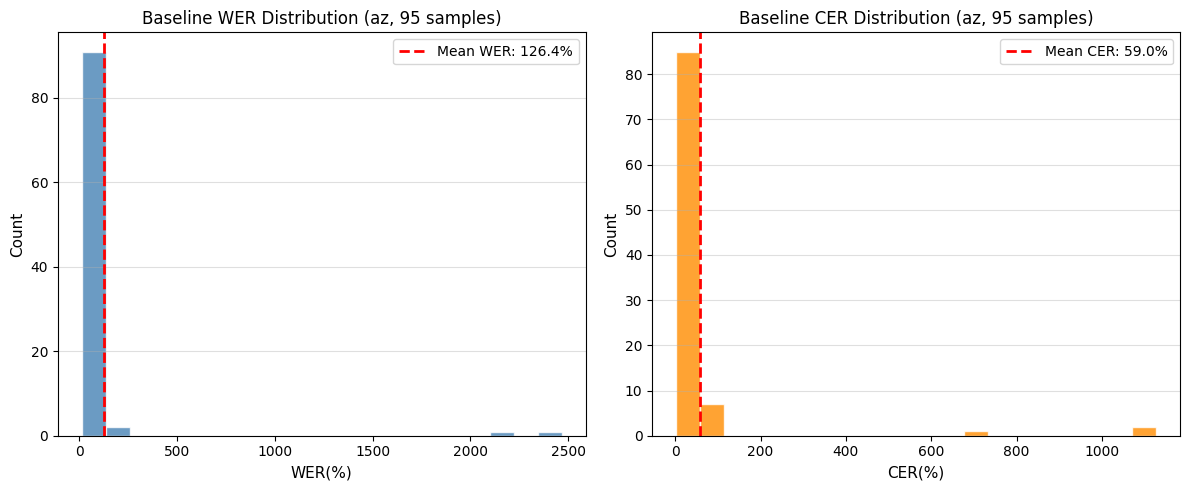

In [ ]:
# WER distribution histogram
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
for ax, data, label, color in zip(
    axes, [sample_wers, sample_cers], ['WER', 'CER'], ['steelblue', 'darkorange']):
    ax.hist([v * 100 for v in data], bins = 20, color = color, alpha = 0.8, edgecolor = 'white')
    ax.axvline(np.mean(data) * 100, color = 'red', linestyle =  '--', linewidth = 2, label = f'Mean {label}: {np.mean(data) * 100:.1f}%')
    ax.set_xlabel(f'{label}(%)', fontsize = 11)
    ax.set_ylabel('Count', fontsize = 11)
    ax.set_title(f'Baseline {label} Distribution (az, {eval_size} samples)', fontsize = 12)
    ax.legend(fontsize = 10)
    ax.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
os.makedirs('results', exist_ok = True)
plt.show()

This code block generates and displays two histograms side-by-side to visualize the distribution of Word Error Rate (WER) and Character Error Rate (CER) across the evaluation samples.

---

**Results according to histograms**:

The generated histograms for WER and CER further visually confirm the extremely poor performance of the baseline `openai/whisper-small` model on Azerbaijani.

-   **High Error Rates**: Both histograms show that the vast majority, if not all, samples have WERs and CERs clustered at very high percentages, often close to or exceeding 100%. This is consistent with the numerical average WER (126.41%) and CER (59.03%) calculated previously.
-   **Flat Distribution or Peaks at Max**: Instead of a distribution centered around a low error rate (which would indicate good performance), the histograms likely show either a flat distribution across high error values or a concentration of samples at the highest possible error rates. This signifies that the model struggled significantly with almost every single sample.
-   **Confirmation of Baseline Failure**: The visual evidence from these plots reinforces the conclusion that without fine-tuning, the Whisper-small model is practically unusable for Azerbaijani speech recognition, producing output that bears little resemblance to the actual audio transcriptions.